In [ ]:
import numpy as np

import torch
from torch.optim import Adam
from pykeen.training import SLCWATrainingLoop

from pykeen.datasets import Dataset
from pykeen.models import TransE
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

from pykeen.training.callbacks import TrainingCallback

c:\Users\zalak\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 1. Define your custom Knowledge Graph facts (Triples)
# Format: (Head, Relation, Tail)
raw_triples = [
    ("Alice", "is_parent_of", "Bob"),
    ("Alice", "is_parent_of", "Charlie"),
    ("Bob", "is_brother_of", "Charlie"),
    ("Charlie", "is_brother_of", "Bob"),
    ("Alice", "lives_in", "Paderborn"),
    ("Bob", "lives_in", "Paderborn"),
]

In [6]:
# Convert the list into a NumPy array
triples_data = np.array(raw_triples)

# 2. Convert raw text into a PyKEEN TriplesFactory
triples_factory = TriplesFactory.from_labeled_triples(triples_data)
triples_factory

TriplesFactory(num_entities=4, num_relations=3, create_inverse_triples=False, num_triples=6)

In [8]:
# Split into training and testing
training_factory, testing_factory = triples_factory.split([0.8, 0.2], random_state=42)

In [9]:
# 3. Intialize TransE model
model = TransE(
    triples_factory=triples_factory,
    embedding_dim=5,
    random_seed=42
)

In [10]:
# Set up Optimizer
optimizer = Adam(
    params = model.get_grad_params(),
    lr = 0.05
)

In [ ]:
# 1. Define a custom tracking rule that PyKEEN will force-run every epoch
class LossPrintingCallback(TrainingCallback):
    def on_epoch_end(self, epoch: int, loss: float, **kwargs):
        
        # PyKEEN automatically provides the current epoch and loss value here
        print(f"Epoch {epoch:3d}/100 | Loss : {loss:.4f}")


# Setup Training Loop
training_loop = SLCWATrainingLoop(
    triples_factory=triples_factory,
    model=model,
    optimizer=optimizer
)

print("--- Printing Loss Decrement via PyKEEN Callback ---")

# 3. Run the entire 100 epochs in ONE line of code
# We pass our custom printing rule into the callbacks list
training_loop.train(
    triples_factory=triples_factory,
    num_epochs=100,      # Let PyKEEN run all 100 internal loops natively
    batch_size=2,
    use_tqdm=False,      # Hides the progress bar so your text outputs cleanly
    callbacks=[LossPrintingCallback()] # <-- This forces the epoch-by-epoch print!
)

--- Printing Loss Decrement via PyKEEN Callback ---


[0.7458277940750122,
 1.3543391625086467,
 0.7074551582336426,
 1.2291720310846965,
 0.46196003754933673,
 0.9670461813608805,
 0.35522568225860596,
 0.27439624071121216,
 0.30195597807566327,
 0.5898475249608358,
 0.2634768486022949,
 0.3417212168375651,
 0.0,
 0.2102485696474711,
 0.20453373591105142,
 0.16713019212086996,
 0.1110695203145345,
 0.23220149676005045,
 0.3251941998799642,
 0.17495652039845785,
 0.3531763156255086,
 0.4200288653373718,
 0.15257964531580606,
 0.34931522607803345,
 0.010737339655558268,
 0.35454392433166504,
 0.36531543731689453,
 0.09015758832295735,
 0.0,
 0.0,
 0.39019350210825604,
 0.4879302978515625,
 0.25225476423899335,
 0.14073538780212402,
 0.3863188823064168,
 0.42042001088460285,
 0.6281607945760092,
 0.3970811367034912,
 0.39164020617802936,
 0.5027956565221151,
 0.5425475438435873,
 0.4834602475166321,
 0.0,
 0.28706930081049603,
 0.32015124956766766,
 0.0,
 0.0,
 0.3890902598698934,
 0.5784812569618225,
 0.1726625363032023,
 0.088833093643188

In [ ]:
# Extract Entity Embeddings (Alice, Bob, etc.)
entity_embeddings = model.entity_representations[0]._embeddings.weight.data
entity_to_id = training_factory.entity_to_id

print(f"{entity_to_id}\n")
print(entity_embeddings)


{'Alice': 0, 'Bob': 1, 'Charlie': 2, 'Paderborn': 3}

tensor([[ 0.5856,  0.6505,  0.3133,  0.2627,  0.2583],
        [ 0.1966,  0.4775,  0.3659,  0.4011, -0.6622],
        [ 0.1618, -0.1305, -0.7232,  0.2975,  0.5875],
        [-0.3774, -0.2289, -0.6638,  0.1325,  0.5890]])


In [ ]:
# Extract Relation Embeddings (is_parent_of, lives_in, etc.)
relation_embeddings = model.relation_representations[0]._embeddings.weight.data
relation_to_id = training_factory.relation_to_id

print(f"{relation_to_id}\n")
print(relation_embeddings)

{'is_brother_of': 0, 'is_parent_of': 1, 'lives_in': 2}

tensor([[-0.0575,  0.5416,  0.5985, -0.0368, -0.5864],
        [-0.3814,  0.1758,  0.6245,  0.6362, -0.1699],
        [ 0.3693, -0.4835, -0.3694, -0.5976, -0.3691]])


In [17]:
# Varify
alice_id = training_factory.entity_to_id["Alice"]
parent_relation_id = training_factory.relation_to_id["is_parent_of"]
bob_id = training_factory.entity_to_id["Bob"]

alice_vector = model.entity_representations[0]._embeddings.weight.data[alice_id]
parent_relation_vector = model.relation_representations[0]._embeddings.weight.data[parent_relation_id]
bob_vector = model.entity_representations[0]._embeddings.weight.data[bob_id]
print("Actual Bob Vector :- ", bob_vector)

predicted_bob_vector = alice_vector + parent_relation_vector
print("Predicted Bob Vector :- ", predicted_bob_vector)

# Find Distance
distance = torch.norm(predicted_bob_vector - bob_vector, p=2).item()
print("True Triple Distance :- ", round(distance, 4))

Actual Bob Vector :-  tensor([-0.0082, -0.4508, -0.6367,  0.5472,  0.3032])
Predicted Bob Vector :-  tensor([ 0.2789, -1.1114,  0.2902,  1.0126,  0.4220])
True Triple Distance :-  1.2683


In [18]:
# Let's check the distance for a false fact: (Alice, is_parent_of, Paderborn)
paderborn_id = training_factory.entity_to_id["Paderborn"]
paderborn_vector = model.entity_representations[0]._embeddings.weight.data[paderborn_id]
false_distance = torch.norm(predicted_bob_vector - paderborn_vector, p=2).item()

print(f"False Triple - Alice, is_parent_of, Paderborn")
print("False Triple Distance :- ", round(false_distance, 4))

False Triple - Alice, is_parent_of, Paderborn
False Triple Distance :-  2.5242


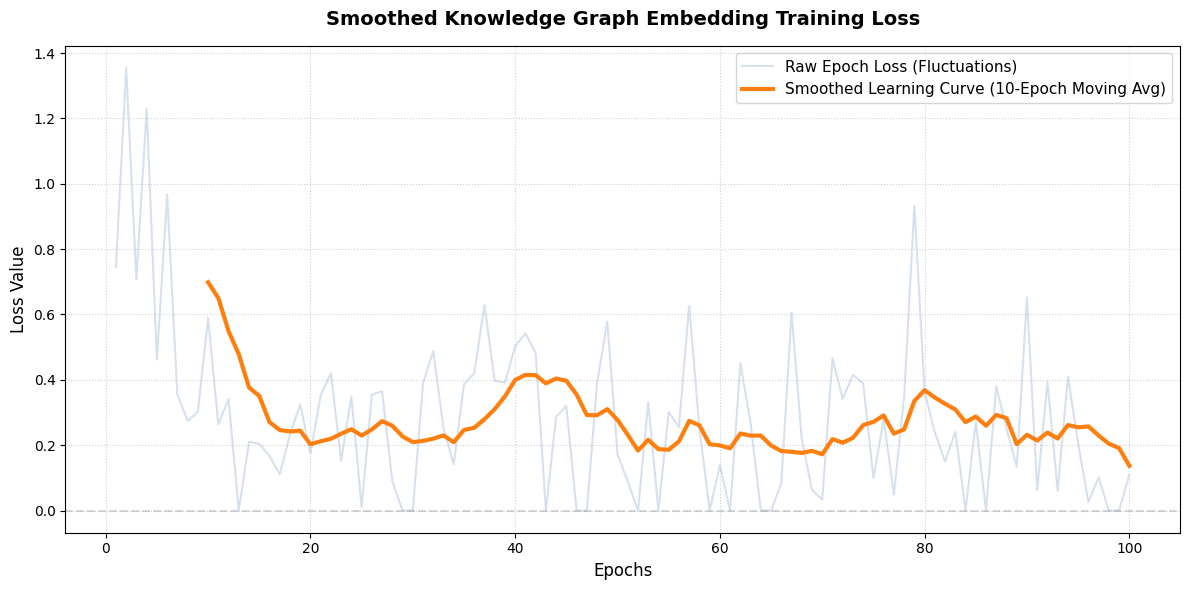

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Your raw list of 100 loss values
loss_history = [
    0.7458277940750122, 1.3543391625086467, 0.7074551582336426, 1.2291720310846965,
    0.46196003754933673, 0.9670461813608805, 0.35522568225860596, 0.27439624071121216,
    0.30195597807566327, 0.5898475249608358, 0.2634768486022949, 0.3417212168375651,
    0.0, 0.2102485696474711, 0.20453373591105142, 0.16713019212086996,
    0.1110695203145345, 0.23220149676005045, 0.3251941998799642, 0.17495652039845785,
    0.3531763156255086, 0.4200288653373718, 0.15257964531580606, 0.34931522607803345,
    0.010737339655558268, 0.35454392433166504, 0.36531543731689453, 0.09015758832295735,
    0.0, 0.0, 0.39019350210825604, 0.4879302978515625,
    0.25225476423899335, 0.14073538780212402, 0.3863188823064168, 0.42042001088460285,
    0.6281607945760092, 0.3970811367034912, 0.39164020617802936, 0.5027956565221151,
    0.5425475438435873, 0.4834602475166321, 0.0, 0.28706930081049603,
    0.32015124956766766, 0.0, 0.0, 0.3890902598698934,
    0.5784812569618225, 0.1726625363032023, 0.08883309364318848, 0.0,
    0.33085091908772785, 0.0, 0.30176734924316406, 0.25594401359558105,
    0.627066453297933, 0.25193997224171955, 0.0, 0.13853361209233603,
    0.0, 0.45161521434783936, 0.2671319246292114, 0.0,
    0.0, 0.08387442429860432, 0.606219212214152, 0.21723743279774985,
    0.06363876660664876, 0.03326650460561117, 0.4648691813151042, 0.3416253725687663,
    0.41528870662053424, 0.38915324211120605, 0.09943862756093343, 0.2801043192545573,
    0.04981466134389242, 0.34870803356170654, 0.9321083823839823, 0.3628680308659871,
    0.23980732758839926, 0.14995364348093668, 0.24148841698964438, 0.0,
    0.27239660422007245, 0.0, 0.379792054494222, 0.25139017899831134,
    0.13401436805725098, 0.652219295501709, 0.06274008750915527, 0.3941238721211751,
    0.0601340134938558, 0.4101678530375163, 0.20456244548161825, 0.026233832041422527,
    0.10216857989629109, 0.0, 0.0, 0.11046220858891805
]

# 2. Define smoothing window (how many epochs to average together)
# A window of 10 means each point is the average of 10 neighboring epochs
window_size = 10
kernel = np.ones(window_size) / window_size

# Use numpy convolution to calculate the rolling average smoothly
smooth_loss = np.convolve(loss_history, kernel, mode='valid')

# 3. Setup the plot dimensions
plt.figure(figsize=(12, 6))
epochs_raw = range(1, len(loss_history) + 1)
epochs_smooth = range(window_size, len(loss_history) + 1)

# 4. Plot both lines for comparison
# The raw data is shown faintly in the background, while the smooth trend is bold
plt.plot(epochs_raw, loss_history, color='#b0c4de', linestyle='-', alpha=0.5, label='Raw Epoch Loss (Fluctuations)')
plt.plot(epochs_smooth, smooth_loss, color='#ff7f0e', linestyle='-', linewidth=3, label='Smoothed Learning Curve (10-Epoch Moving Avg)')

# 5. Styling and labels
plt.title('Smoothed Knowledge Graph Embedding Training Loss', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)

plt.axhline(0.0, color='gray', linestyle='--', alpha=0.3)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()